In [20]:
# ============================================================
# 1. IMPORTAR LIBRERÍAS
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [21]:
# ============================================================
# 2. CARGAR DATASET DE CORRELACIÓN
# ============================================================

df_corr = pd.read_csv("https://raw.githubusercontent.com/BAcost26/Datos-python/refs/heads/main/Parcial4/clave_A_correlacion.csv")

print("Primeras filas del dataset:")
display(df_corr.head())

print("Cantidad de filas y columnas:")
print(df_corr.shape)

print("Tipos de datos:")
print(df_corr.dtypes)

Primeras filas del dataset:


,cliente_id,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
0,A-C0001,37,468,4,36.45,8.73,1,7,22.02,297.03
1,A-C0002,27,1076,8,63.31,9.15,0,6,24.89,524.34
2,A-C0003,19,948,5,44.25,8.33,0,1,26.58,181.14
3,A-C0004,41,832,8,63.11,9.90,0,5,16.22,532.66
4,A-C0005,30,1287,6,86.49,7.83,1,4,20.42,557.44


Cantidad de filas y columnas:
(221, 10)
Tipos de datos:
cliente_id             object
edad                    int64
ingresos_mensuales      int64
frecuencia_compra       int64
ticket_promedio       float64
satisfaccion          float64
reclamos                int64
uso_app                 int64
tiempo_respuesta      float64
consumo_total         float64
dtype: object


In [23]:
# ============================================================
# 3. IDENTIFICAR VARIABLES NUMÉRICAS
# ============================================================

variables_numericas = df_asociacion.select_dtypes(include=["int64", "float64"]).columns

print("Variables numéricas identificadas:")
print(variables_numericas)

Variables numéricas identificadas:
Index(['edad', 'ingresos_mensuales', 'frecuencia_compra', 'ticket_promedio',
       'satisfaccion', 'reclamos', 'uso_app', 'tiempo_respuesta',
       'consumo_total'],
      dtype='object')


In [24]:
# ============================================================
# 4. REVISAR NULOS, DUPLICADOS Y VALORES ATÍPICOS
# ============================================================

print("Valores nulos:")
print(df_corr.isnull().sum())

print("\nDuplicados:")
print(df_corr.duplicated().sum())

print("\nEstadísticas descriptivas:")
display(df_corr.describe())

Valores nulos:
cliente_id            0
edad                  0
ingresos_mensuales    0
frecuencia_compra     0
ticket_promedio       1
satisfaccion          1
reclamos              0
uso_app               0
tiempo_respuesta      1
consumo_total         0
dtype: int64

Duplicados:
1

Estadísticas descriptivas:


,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
count,221.000000,221.000000,221.000000,220.000000,220.000000,221.000000,221.000000,220.000000,221.000000
mean,33.981900,853.868778,7.018100,55.187273,7.540409,1.556561,5.095023,21.978227,410.161448
std,10.037187,251.337379,3.046554,16.185683,1.160736,1.579043,1.934148,5.786844,175.550586
min,18.000000,300.000000,1.000000,14.660000,2.390000,0.000000,0.000000,9.260000,72.590000
25%,27.000000,692.000000,6.000000,42.662500,6.910000,1.000000,4.000000,17.710000,289.820000
50%,34.000000,854.000000,7.000000,55.585000,7.630000,1.000000,5.000000,21.665000,389.220000
75%,41.000000,1012.000000,8.000000,67.195000,8.312500,2.000000,6.000000,25.722500,504.470000
max,60.000000,1517.000000,27.000000,96.050000,9.900000,9.000000,10.000000,40.160000,1291.030000


In [15]:
# ============================================================
# 5. TRATAMIENTO DE VALORES NULOS
# ============================================================

# Rellenar valores nulos numéricos con la mediana
for col in variables_numericas:
    df_corr[col] = df_corr[col].fillna(df_corr[col].median())

print("Valores nulos después de limpieza:")
print(df_corr.isnull().sum())

Valores nulos después de limpieza:
cliente_id            0
edad                  0
ingresos_mensuales    0
frecuencia_compra     0
ticket_promedio       0
satisfaccion          0
reclamos              0
uso_app               0
tiempo_respuesta      0
consumo_total         0
dtype: int64


In [16]:
# ============================================================
# 6. DETECCIÓN GENERAL DE VALORES ATÍPICOS CON IQR
# ============================================================

for col in variables_numericas:
    Q1 = df_corr[col].quantile(0.25)
    Q3 = df_corr[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    atipicos = df_corr[
        (df_corr[col] < limite_inferior) |
        (df_corr[col] > limite_superior)
    ]

    print(f"{col}: {len(atipicos)} valores atípicos detectados")

edad: 0 valores atípicos detectados
ingresos_mensuales: 1 valores atípicos detectados
frecuencia_compra: 10 valores atípicos detectados
ticket_promedio: 0 valores atípicos detectados
satisfaccion: 5 valores atípicos detectados
reclamos: 17 valores atípicos detectados
uso_app: 4 valores atípicos detectados
tiempo_respuesta: 1 valores atípicos detectados
consumo_total: 4 valores atípicos detectados


In [27]:
# ============================================================
# 7. CALCULAR MATRIZ DE CORRELACIÓN
# ============================================================

matriz_corr = df_corr[variables_numericas].corr()

print("Matriz de correlación:")
display(matriz_corr)

Matriz de correlación:


,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
edad,1.000000,-0.007918,-0.039381,0.134206,-0.104730,0.049394,0.027718,0.061536,0.057357
ingresos_mensuales,-0.007918,1.000000,0.052848,0.555589,-0.004644,0.028543,-0.093862,-0.065410,0.299562
frecuencia_compra,-0.039381,0.052848,1.000000,0.103280,0.246912,-0.121158,0.574399,-0.331774,0.833677
ticket_promedio,0.134206,0.555589,0.103280,1.000000,0.068289,-0.058241,0.014096,-0.101673,0.551161
satisfaccion,-0.104730,-0.004644,0.246912,0.068289,1.000000,-0.773891,0.096484,-0.546874,0.328013
reclamos,0.049394,0.028543,-0.121158,-0.058241,-0.773891,1.000000,0.082322,0.472124,-0.208554
uso_app,0.027718,-0.093862,0.574399,0.014096,0.096484,0.082322,1.000000,-0.259140,0.542587
tiempo_respuesta,0.061536,-0.065410,-0.331774,-0.101673,-0.546874,0.472124,-0.259140,1.000000,-0.380181
consumo_total,0.057357,0.299562,0.833677,0.551161,0.328013,-0.208554,0.542587,-0.380181,1.000000


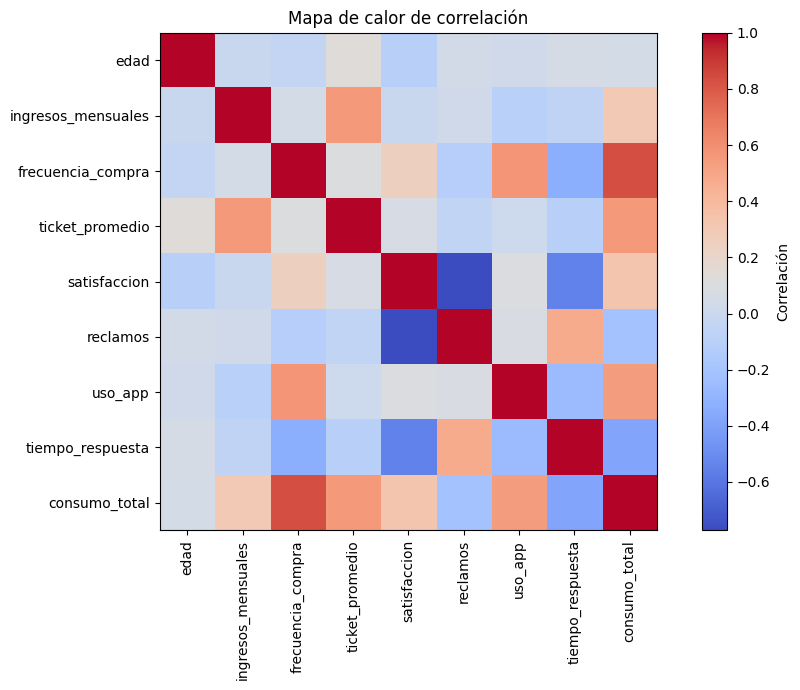

In [18]:
# ============================================================
# 8. CREAR MAPA DE CALOR DE CORRELACIÓN
# ============================================================

plt.figure(figsize=(10, 7))
plt.imshow(matriz_corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar(label="Correlación")

plt.xticks(range(len(matriz_corr.columns)), matriz_corr.columns, rotation=90)
plt.yticks(range(len(matriz_corr.columns)), matriz_corr.columns)

plt.title("Mapa de calor de correlación")
plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# 9. IDENTIFICAR CORRELACIONES POSITIVAS Y NEGATIVAS
# ============================================================

correlaciones = matriz_corr.unstack().reset_index()
correlaciones.columns = ["Variable 1", "Variable 2", "Correlación"]

# Eliminar correlación de la misma variable
correlaciones = correlaciones[
    correlaciones["Variable 1"] != correlaciones["Variable 2"]
]

# Evitar duplicados
correlaciones["par"] = correlaciones.apply(
    lambda x: tuple(sorted([x["Variable 1"], x["Variable 2"]])),
    axis=1
)

correlaciones = correlaciones.drop_duplicates("par").drop(columns="par")

positivas = correlaciones.sort_values(by="Correlación", ascending=False)
negativas = correlaciones.sort_values(by="Correlación", ascending=True)

print("Correlaciones positivas más importantes:")
display(positivas.head(5))

print("Correlaciones negativas más importantes:")
display(negativas.head(5))

Correlaciones positivas más importantes:


,Variable 1,Variable 2,Correlación
26,frecuencia_compra,consumo_total,0.833677
24,frecuencia_compra,uso_app,0.574399
12,ingresos_mensuales,ticket_promedio,0.555374
35,ticket_promedio,consumo_total,0.550256
62,uso_app,consumo_total,0.542587


Correlaciones negativas más importantes:


,Variable 1,Variable 2,Correlación
41,satisfaccion,reclamos,-0.772081
43,satisfaccion,tiempo_respuesta,-0.544597
71,tiempo_respuesta,consumo_total,-0.379363
25,frecuencia_compra,tiempo_respuesta,-0.331276
61,uso_app,tiempo_respuesta,-0.258176


In [28]:
# ============================================================
# 10. EXPLICAR 4 RELACIONES ENCONTRADAS
# ============================================================

print("INTERPRETACIÓN DE RELACIONES:")

for i, fila in positivas.head(2).iterrows():
    print(f"- Existe una correlación positiva entre {fila['Variable 1']} y {fila['Variable 2']} "
          f"de {fila['Correlación']:.2f}. Esto indica que cuando una variable aumenta, "
          f"la otra también tiende a aumentar.")

for i, fila in negativas.head(2).iterrows():
    print(f"- Existe una correlación negativa entre {fila['Variable 1']} y {fila['Variable 2']} "
          f"de {fila['Correlación']:.2f}. Esto indica que cuando una variable aumenta, "
          f"la otra tiende a disminuir.")

INTERPRETACIÓN DE RELACIONES:
- Existe una correlación positiva entre frecuencia_compra y consumo_total de 0.83. Esto indica que cuando una variable aumenta, la otra también tiende a aumentar.
- Existe una correlación positiva entre frecuencia_compra y uso_app de 0.57. Esto indica que cuando una variable aumenta, la otra también tiende a aumentar.
- Existe una correlación negativa entre satisfaccion y reclamos de -0.77. Esto indica que cuando una variable aumenta, la otra tiende a disminuir.
- Existe una correlación negativa entre satisfaccion y tiempo_respuesta de -0.54. Esto indica que cuando una variable aumenta, la otra tiende a disminuir.


In [ ]:
# ============================================================
# 11. CONCLUSIÓN DEL ANÁLISIS DE CORRELACIÓN
# ============================================================

print("CONCLUSIÓN:")
print("El análisis de correlación permite identificar relaciones entre las variables de los clientes.")
print("Estas relaciones pueden ayudar a la empresa a comprender mejor el comportamiento de compra,")
print("la satisfacción, el consumo total, los reclamos y el uso de la aplicación.")